In [2]:
from google.colab import files
uploaded = files.upload()

Saving Reviews.csv to Reviews.csv


In [3]:
import pandas as pd

df = pd.read_csv('Reviews.csv')

print(df.shape)
df.head()

(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [4]:
print(df.shape)
print(df.isnull().sum())
print(df['Score'].value_counts().sort_index())

(568454, 10)
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
dtype: int64
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


In [5]:
# Take a random sample for manageable processing time
df_sample = df.sample(n=15000, random_state=42).reset_index(drop=True)

# Create rating-based sentiment label (our "ground truth")
def rating_to_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df_sample['rating_sentiment'] = df_sample['Score'].apply(rating_to_sentiment)

print(df_sample['rating_sentiment'].value_counts())
df_sample.head()

rating_sentiment
positive    11719
negative     2149
neutral      1132
Name: count, dtype: int64


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text,rating_sentiment
0,165257,B000EVG8J2,A1L01D2BD3RKVO,"B. Miller ""pet person""",0,0,5,1268179200,Crunchy & Good Gluten-Free Sandwich Cookies!,Having tried a couple of other brands of glute...,positive
1,231466,B0000BXJIS,A3U62RE5XZDP0G,Marty,0,0,5,1298937600,great kitty treats,My cat loves these treats. If ever I can't fin...,positive
2,427828,B008FHUFAU,AOXC0JQQZGGB6,Kenneth Shevlin,0,2,3,1224028800,COFFEE TASTE,A little less than I expected. It tends to ha...,neutral
3,433955,B006BXV14E,A3PWPNZVMNX3PA,rareoopdvds,0,1,2,1335312000,So the Mini-Wheats were too big?,"First there was Frosted Mini-Wheats, in origin...",negative
4,70261,B007I7Z3Z0,A1XNZ7PCE45KK7,Og8ys1,0,2,5,1334707200,Great Taste . . .,and I want to congratulate the graphic artist ...,positive


In [6]:
!pip install vaderSentiment -q

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    scores = analyzer.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df_sample['vader_sentiment'] = df_sample['Text'].apply(get_vader_sentiment)

print(df_sample['vader_sentiment'].value_counts())
df_sample[['Text', 'Score', 'rating_sentiment', 'vader_sentiment']].head(10)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.6 MB/s eta 0:00:00
vader_sentiment
positive    13261
negative     1445
neutral       294
Name: count, dtype: int64


,Text,Score,rating_sentiment,vader_sentiment
0,Having tried a couple of other brands of glute...,5,positive,positive
1,My cat loves these treats. If ever I can't fin...,5,positive,positive
2,A little less than I expected. It tends to ha...,3,neutral,positive
3,"First there was Frosted Mini-Wheats, in origin...",2,negative,positive
4,and I want to congratulate the graphic artist ...,5,positive,positive
5,Please add more Pineapple flavor to your packa...,4,positive,positive
6,I absolutely love Yorkshire tea and am so glad...,5,positive,positive
7,I have such a hard time finding loose tea loca...,5,positive,positive
8,"Previously, I've attempted a recipe with white...",4,positive,positive
9,I make pancakes or waffles every Saturday morn...,5,positive,positive


In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import pandas as pd

# Confusion matrix: rows = actual (rating-based), columns = predicted (VADER)
labels = ['negative', 'neutral', 'positive']
cm = confusion_matrix(df_sample['rating_sentiment'], df_sample['vader_sentiment'], labels=labels)
cm_df = pd.DataFrame(cm, index=[f'actual_{l}' for l in labels], columns=[f'vader_{l}' for l in labels])
print(cm_df)

print("\n--- Classification Report ---")
print(classification_report(df_sample['rating_sentiment'], df_sample['vader_sentiment'], labels=labels))

# Isolate the mismatches for closer inspection
mismatches = df_sample[df_sample['rating_sentiment'] != df_sample['vader_sentiment']]
print(f"\nTotal mismatches: {len(mismatches)} out of {len(df_sample)} ({len(mismatches)/len(df_sample)*100:.1f}%)")

# The most interesting case: negative reviews that VADER called positive
neg_to_pos = mismatches[(mismatches['rating_sentiment'] == 'negative') & (mismatches['vader_sentiment'] == 'positive')]
print(f"\nNegative-rated reviews VADER called positive: {len(neg_to_pos)}")
neg_to_pos[['Text', 'Score']].head(10)

                 vader_negative  vader_neutral  vader_positive
actual_negative             873            106            1170
actual_neutral              190             38             904
actual_positive             382            150           11187

--- Classification Report ---
              precision    recall  f1-score   support

    negative       0.60      0.41      0.49      2149
     neutral       0.13      0.03      0.05      1132
    positive       0.84      0.95      0.90     11719

    accuracy                           0.81     15000
   macro avg       0.53      0.46      0.48     15000
weighted avg       0.76      0.81      0.77     15000


Total mismatches: 2902 out of 15000 (19.3%)

Negative-rated reviews VADER called positive: 1170


,Text,Score
3,"First there was Frosted Mini-Wheats, in origin...",2
22,It sure would be nice if they stated ANYWHERE ...,1
30,I bought this item for my dog to play with. Sh...,1
50,"With a legendary name like Gevalia, I was disa...",2
70,I was definately expecting a better product fr...,1
79,Too soft: I just used this sugar to bake one o...,2
81,i have just brought one small package of Canid...,1
97,I bought this because I would buy Kirkland (Co...,1
123,I'm used to buying 12 poptarts for $2.89 in my...,2
143,I'm not sure if the four I purchased were from...,1


In [8]:
pd.set_option('display.max_colwidth', None)
for i, row in neg_to_pos.head(5).iterrows():
    print(f"Score: {row['Score']} | Text: {row['Text']}\n{'-'*80}")

Score: 2 | Text: First there was Frosted Mini-Wheats, in original size, then there was Frosted Mini-Wheats Bite Size. Well, if for some reason those were too much of a mouthful, we now have Frosted Mini-Wheats Little Bits. Yes, these are about half the size of the Bite Size versions. This particular one is "Cinnamon Roll".<br /><br />There is nothing new to the table here with the exception of size, which I is unnecessary. Personally, I like original flavor and size the best. But the Bite Size edition were accommodating. These come off as a desperate attempt to give attention to a brand that needs some sort of life put back into it and all they came up with was making them smaller and having a new flavor, which is actually too sweet for me.<br /><br />A serving size is approximately 47 biscuits. Thats 1 gram of polyunsaturated fat, 46 grams of carbohydrates, 6g fiber, 12g of sugar, 5g of protein and 200mg of potassium. Generally they look good but I guess those that are watching their 

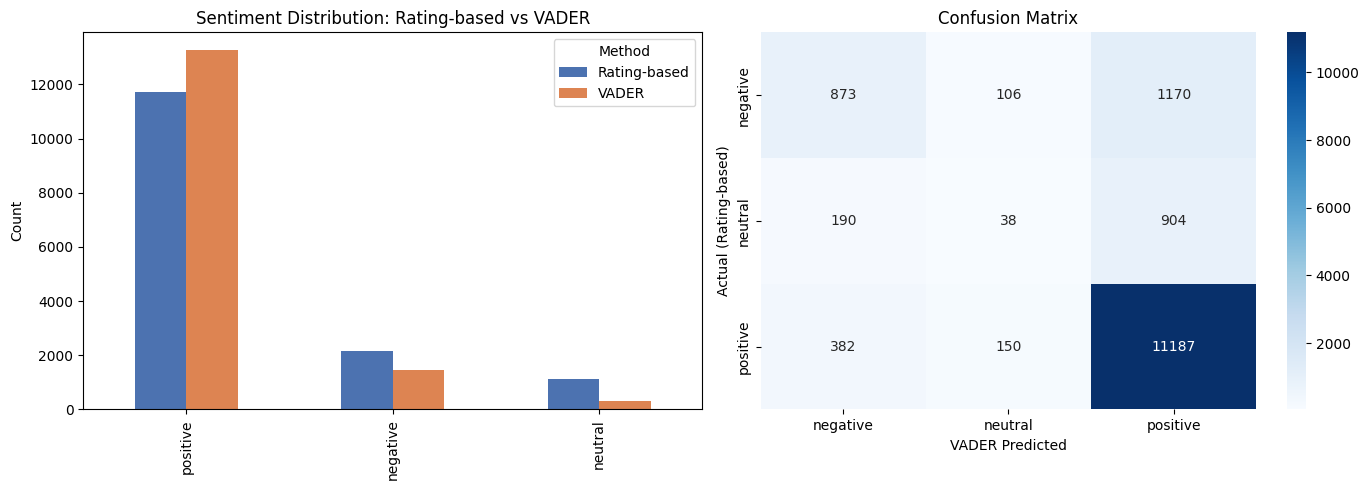

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment distribution comparison
comparison_df = pd.DataFrame({
    'Rating-based': df_sample['rating_sentiment'].value_counts(),
    'VADER': df_sample['vader_sentiment'].value_counts()
})
comparison_df.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Sentiment Distribution: Rating-based vs VADER')
axes[0].set_ylabel('Count')
axes[0].legend(title='Method')

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_xlabel('VADER Predicted')
axes[1].set_ylabel('Actual (Rating-based)')
axes[1].set_title('Confusion Matrix')

plt.tight_layout()
plt.savefig('sentiment_comparison.png', dpi=150)
plt.show()

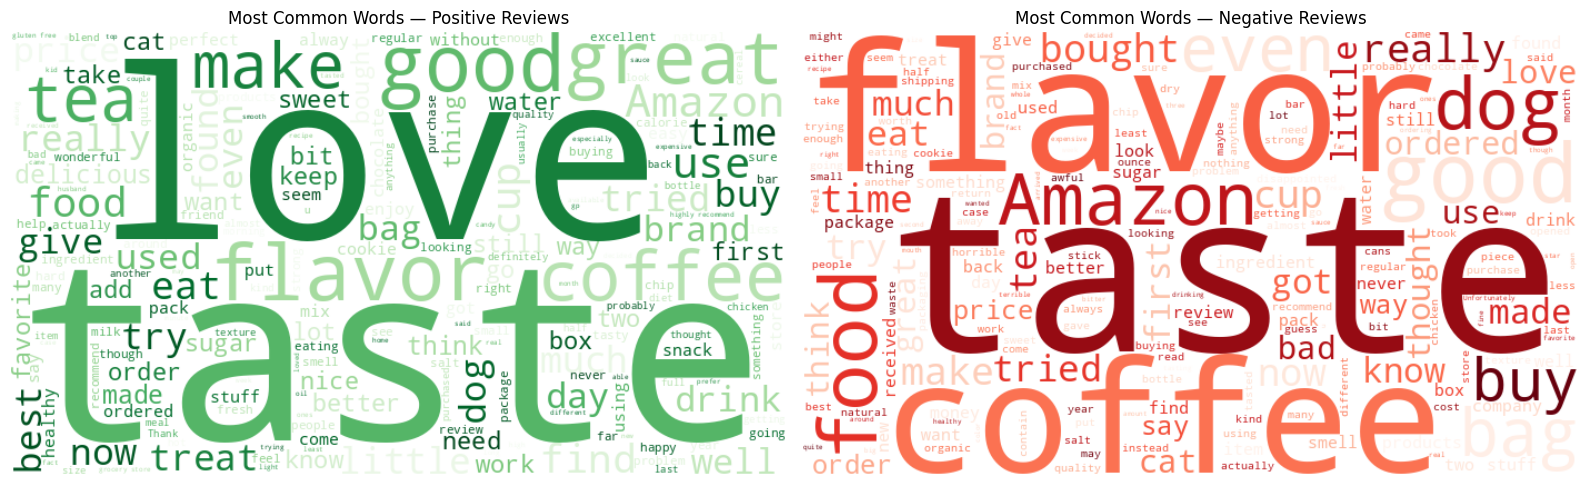

In [10]:
!pip install wordcloud -q
from wordcloud import WordCloud, STOPWORDS

stopwords = set(STOPWORDS)
stopwords.update(['br', 'href', 'one', 'will', 'product'])

positive_text = ' '.join(df_sample[df_sample['rating_sentiment']=='positive']['Text'])
negative_text = ' '.join(df_sample[df_sample['rating_sentiment']=='negative']['Text'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

wc_pos = WordCloud(width=700, height=400, background_color='white', stopwords=stopwords, colormap='Greens').generate(positive_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Most Common Words — Positive Reviews')
axes[0].axis('off')

wc_neg = WordCloud(width=700, height=400, background_color='white', stopwords=stopwords, colormap='Reds').generate(negative_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Most Common Words — Negative Reviews')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

# Task 4: Sentiment Analysis — Amazon Fine Food Reviews

**Objective:** Compare rating-derived sentiment (ground truth from star ratings) against
VADER's text-based sentiment prediction on ~568K Amazon food reviews, to evaluate how well
a lexicon-based model captures actual customer sentiment — and identify where it fails.

**Dataset:** Amazon Fine Food Reviews (Stanford SNAP), 568,454 reviews. A random sample of
15,000 reviews was used for VADER scoring due to compute constraints.

## Key Findings

- **Overall accuracy: 81%**, but this is misleading — driven almost entirely by the majority
  positive class (95% recall). Negative recall was only 41%, and neutral sentiment was nearly
  undetectable (3% recall).
- **VADER systematically misreads negative reviews that open with praise.** In 1,170 cases,
  a 1–2 star review was scored positive by VADER. Manual inspection showed a consistent
  pattern: reviewers often compliment a specific aspect (packaging, aroma, brand reputation)
  before delivering a negative overall verdict — VADER's compound score aggregates polarity
  across the whole text, so a short negative conclusion is outweighed by a longer positive
  build-up.
- **Both methods agree complaints center on taste/flavor**, not shipping or price — word
  clouds show "taste," "flavor," and "coffee" dominate negative reviews just as much as
  positive ones, suggesting dissatisfaction is primarily about the product not meeting
  taste expectations.
- **Implication:** for business use cases needing accurate negative-sentiment detection
  (e.g., flagging complaints for follow-up), a lexicon-based model like VADER alone is
  insufficient — it would miss roughly 6 in 10 genuinely negative reviews.